---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 16. Visualização de filtros aprendidos

Neste capítulo exploramos um dos temas mais fascinantes da aprendizagem profunda em visão computacional: **como visualizar e interpretar os filtros aprendidos por redes convolucionais**.  
Depois de termos visto, nos notebooks anteriores, como as convoluções funcionam e como os autoencoders aprendem representações latentes, este passo leva-nos a olhar “por dentro” de modelos já treinados — como a VGG16 ou a ResNet — para compreender **o que cada camada realmente vê e aprende**.

O objetivo é traduzir o comportamento interno da rede para o domínio visual: observar padrões, texturas e formas que os filtros detetam em diferentes níveis de profundidade.  
Nas primeiras camadas veremos contornos e orientações simples; nas mais profundas, estruturas compostas e partes de objetos.

Este exercício não é apenas visual: é uma ferramenta de **interpretação e confiança** nos modelos de *deep learning*, permitindo perceber como a rede transforma píxeis em abstrações progressivamente mais complexas.

## 16.1. Preparação do ambiente e funções auxiliares

Nesta célula inicial configuramos o ambiente de trabalho e preparamos as funções básicas de visualização.

### 1. Bibliotecas utilizadas

- **PyTorch (`torch`, `torch.nn`)** — base para definição e execução de modelos.  
- **Torchvision** — fornece modelos pré-treinados (ex.: VGG, ResNet) e ferramentas de transformação de imagens.  
- **Matplotlib e NumPy** — para visualização e manipulação numérica.  
- **PIL e SciPy** — para leitura e pré-processamento adicional de imagens.

### 2. Configuração do dispositivo

A variável `device` define automaticamente se o cálculo será feito em GPU (`cuda`) ou CPU, garantindo compatibilidade entre diferentes máquinas.

### 3. Transformação de imagem

O objeto `transform` aplica operações de pré-processamento necessárias para alimentar o modelo:
- redimensionamento para 224×224 píxeis (dimensão padrão da VGG e ResNet);  
- conversão para tensor PyTorch (`ToTensor()`).

### 4. Função de visualização `imshow()`

A função `imshow()` simplifica a apresentação de tensores de imagem:
- converte o tensor para formato NumPy;  
- ajusta a ordem dos eixos (caso RGB);  
- e exibe a imagem com título opcional e eixos ocultos.

Esta função será usada repetidamente para visualizar tanto **imagens de entrada** como **mapas de ativação** extraídos das camadas da rede.

In [14]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage
import requests
from io import BytesIO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def imshow(tensor, title=None):
    img = tensor.cpu().clone().squeeze()
    if img.ndim == 3:
        img = img.permute(1, 2, 0)
    plt.imshow(img, cmap="gray")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

Device: cpu


## 16.2. Carregamento do modelo pré-treinado (VGG16)

Nesta etapa recorremos a um modelo **VGG16** pré-treinado no conjunto de dados **ImageNet**, amplamente utilizado para tarefas de reconhecimento de objetos.  
Este modelo serve como um exemplo real de rede convolucional profunda, cujos filtros aprenderam a detetar padrões visuais de complexidade crescente.

### 1. Carregamento do modelo
- `models.vgg16(weights=models.VGG16_Weights.DEFAULT)` cria uma instância da VGG16 com pesos já treinados.  
- `.to(device)` envia o modelo para GPU ou CPU conforme a disponibilidade.  
- `.eval()` coloca a rede em modo de avaliação, desativando o *dropout* e outras operações específicas do treino.

### 2. Estrutura inicial da rede
O objeto `model.features` contém a **parte convolucional** da VGG16 — uma sequência de camadas que extrai descritores visuais.  
Ao imprimir apenas as primeiras cinco camadas (`model.features[:5]`), podemos observar:

(0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(1): ReLU(inplace=True)
(2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
(3): ReLU(inplace=True)
(4): MaxPool2d(kernel_size=2, stride=2, padding=0)

Estas camadas formam o **bloco inicial de convolução**, responsável por identificar contornos, gradientes e texturas simples nas imagens.

### 3. Objetivo didático
A partir deste ponto, iremos:
- inspecionar os **filtros aprendidos** nas camadas convolucionais iniciais;  
- visualizar as **respostas (ativação)** produzidas por esses filtros quando uma imagem é introduzida;  
- e comparar visualmente os padrões captados com filtros clássicos de processamento de imagem, como Sobel ou Gabor.

Este é o primeiro passo para compreender, de forma visual, **o que uma rede convolucional realmente aprende**.

In [2]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device).eval()
print(model.features[:5])

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/pedropestana/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|████████████████████████████████████████| 528M/528M [01:46<00:00, 5.18MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


## 16.3. Visualização dos filtros aprendidos (primeira camada convolucional)

Nesta célula extraímos e visualizamos os **pesos da primeira camada convolucional** da VGG16.  
Estes filtros são o resultado de um treino massivo sobre milhões de imagens do conjunto ImageNet e representam o ponto de partida da hierarquia visual da rede.

### 1. Extração dos pesos

- `model.features[0]` corresponde à primeira camada `Conv2d(3, 64, kernel_size=3, stride=1, padding=1)`.  
- O tensor `first_conv.weight` contém os **coeficientes aprendidos** (os valores do kernel) com dimensão `(64, 3, 3, 3)`:  
  - 64 filtros (saídas),  
  - 3 canais de entrada (RGB),  
  - tamanho espacial 3×3.  
- Ao movermos os dados para a CPU e clonarmos (`.data.cpu().clone()`), evitamos alterar acidentalmente os pesos originais do modelo.

### 2. Normalização para visualização

Os valores dos filtros são normalizados para o intervalo \([0,1]\), de modo a que as diferenças relativas entre canais de cor possam ser representadas corretamente em imagem:
$$
w' = \frac{w - w_{\min}}{w_{\max} - w_{\min}}
$$

### 3. Visualização dos filtros

- São exibidos **32 dos 64 filtros** da primeira camada (8×4 grelha).  
- Cada filtro é convertido para formato RGB (`permute(1, 2, 0)`) e visualizado como uma pequena textura colorida.

### 4. Interpretação

Os padrões observados correspondem a **filtros de baixa complexidade**, que captam características visuais elementares:
- **transições de cor e intensidade**,  
- **bordas orientadas**,  
- **pequenas texturas e gradientes locais**.

Estes filtros funcionam como os “neurónios visuais” iniciais da rede, detetando **características primitivas** que servirão de base para representações mais abstratas nas camadas seguintes.

### 5. Valor didático

Esta visualização concretiza um conceito fundamental:
- As redes convolucionais não aprendem *imagens completas*, mas **operações locais de deteção de padrões**.  
- Cada camada vai reutilizando e combinando estas respostas simples para construir representações progressivamente mais complexas.

Nos próximos passos, veremos **como estas mesmas camadas respondem** quando lhes fornecemos uma imagem real — visualizando não apenas os filtros, mas também as **ativaçãoes internas** que produzem.

Formato da primeira layer conv: torch.Size([64, 3, 3, 3])


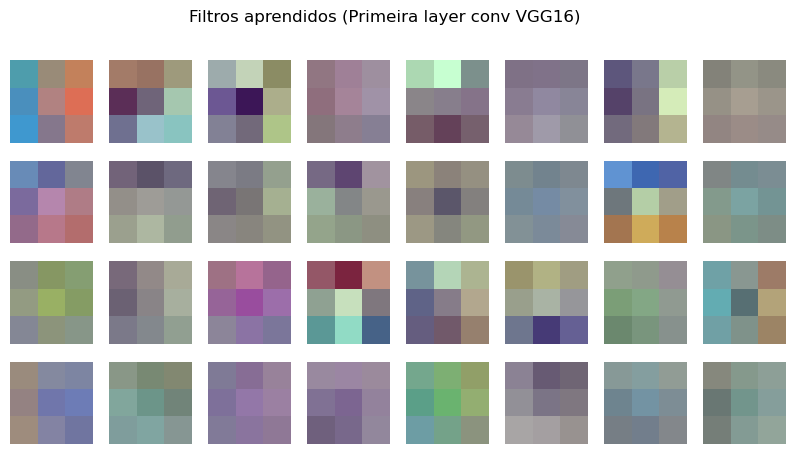

In [20]:
first_conv = model.features[0]
weights = first_conv.weight.data.cpu().clone()

print("Formato da primeira layer conv:", weights.shape)

w = weights.clone()
w_min, w_max = w.min(), w.max()
w = (w - w_min) / (w_max - w_min)

# Plot subset of kernels
n_filters = 32
cols = 8
rows = n_filters // cols
plt.figure(figsize=(10, 5))
for i in range(n_filters):
    plt.subplot(rows, cols, i + 1)
    kernel = w[i].permute(1, 2, 0).numpy()
    plt.imshow(kernel)
    plt.axis("off")
plt.suptitle("Filtros aprendidos (Primeira layer conv VGG16)")
plt.show()

## 16.4. Preparação da imagem de teste

Nesta etapa escolhemos uma imagem real — neste caso, um retrato de um cão — para analisar como a VGG16 processa padrões visuais ao longo das suas camadas convolucionais.

### 1. Carregamento da imagem

- A imagem é obtida diretamente a partir de um URL público (Wikimedia Commons).  
- O ficheiro é lido através de `requests.get()` e convertido para formato **RGB** com `PIL.Image.open()`.  
- O método `.convert("RGB")` garante compatibilidade com o modelo, que espera três canais de entrada.

### 2. Pré-processamento

A imagem é transformada usando o mesmo *pipeline* definido anteriormente:
- `Resize((224,224))` — redimensiona para o tamanho padrão da VGG16;  
- `ToTensor()` — converte para tensor PyTorch, normalizando os valores para o intervalo \([0,1]\).

O tensor final tem forma `(1, 3, 224, 224)`, onde:
- `1` corresponde ao tamanho do lote (*batch size*);  
- `3` aos canais de cor;  
- `224×224` à resolução espacial.

### 3. Visualização

A função `imshow()` exibe a imagem processada no formato correto, servindo como referência visual para as ativações que analisaremos nas células seguintes.

### 4. Objetivo didático

Esta imagem será utilizada para:
- visualizar as **respostas (ativações)** dos filtros das primeiras camadas da VGG16;  
- compreender **que tipo de informação** cada camada extrai da imagem;  
- e observar a progressão de representações desde **bordas e texturas simples** até **padrões semânticos mais complexos**.

Em suma, passamos da análise dos **filtros aprendidos** (o que a rede *sabe*) para a análise das **respostas geradas** (o que a rede *vê*).

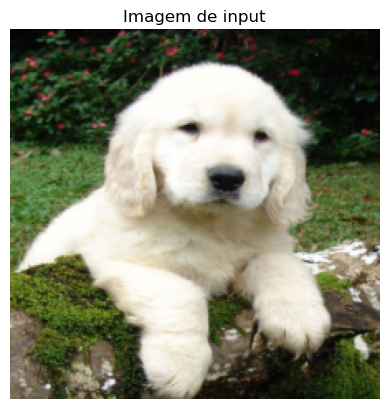

In [36]:
url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)",
    "Accept": "image/*",
    "Accept-Encoding": "identity"
}

response = requests.get(url, headers=headers, stream=True, timeout=15)
response.raise_for_status()

img_pil = Image.open(BytesIO(response.content)).convert("RGB")
img_tensor = transform(img_pil).unsqueeze(0).to(device)

imshow(img_tensor[0], "Imagem de input")

## 16.5. Visualização das ativações internas (feature maps)

Nesta célula exploramos o funcionamento interno da VGG16, observando as **ativaçãoes geradas nas primeiras camadas convolucionais** quando a imagem de input é processada pela rede.

### 1. Função `get_feature_maps()`

A função utiliza o mecanismo de *forward hooks* do PyTorch para **interceptar as saídas intermédias** de camadas específicas do modelo:

- Os *hooks* são registados temporariamente em camadas indicadas por índice (neste caso, `layers=(0, 3)` correspondem às duas primeiras convoluções da VGG16).  
- Durante o *forward pass*, o conteúdo de cada camada é guardado no dicionário `activations`.  
- Após a execução, os *hooks* são removidos para evitar efeitos colaterais.

O resultado é um conjunto de **tensores tridimensionais** (C × H × W) onde:
- `C` representa o número de filtros (ou mapas de características);  
- `H` e `W` representam a resolução espacial das respostas.

### 2. Visualização das ativações

Para cada camada observada:
- Selecionam-se **16 mapas de ativação** (em escala de cinzentos).  
- Cada mapa mostra **a intensidade de resposta de um filtro específico** à imagem de entrada.  
- Os mapas são dispostos numa grelha (8×2) para facilitar a comparação visual.

### 3. Interpretação

As diferenças entre as duas camadas são reveladoras:

- A **primeira camada (layer 0)** deteta padrões visuais elementares — *bordas, contornos, gradientes de cor e orientação.*  
  É possível observar que algumas ativações respondem fortemente à **silhueta do cão** ou às **linhas diagonais do chão**, enquanto outras permanecem quase negras, indicando que os respetivos filtros **não foram estimulados** por essa imagem em particular.  

- A **segunda camada (layer 3)** já combina essas respostas simples em estruturas mais compostas — *texturas, sombras e regiões coerentes.*  
  Nota-se que certas ativações começam a destacar áreas mais amplas, como o **tronco do animal** ou o **pavimento ao fundo**, refletindo uma perceção mais global da cena.

Apesar de visualmente semelhantes às imagens originais, estas representações são **altamente abstratas**:  
cada mapa de ativação é uma “resposta seletiva” de um filtro treinado para reconhecer padrões específicos (orientações, intensidades, texturas).

> Em resumo: o que vemos nestas grelhas não são imagens reconstruídas, mas **mapas de sensibilidade** que revelam **que partes da imagem são mais relevantes para cada filtro**.

### 4. Objetivo didático

Esta visualização permite compreender empiricamente a ideia central das redes convolucionais:
> Cada camada aprende um conjunto de filtros especializados em extrair padrões de complexidade crescente,  
> evoluindo de descritores locais (bordas e cores) para representações semânticas (formas e objetos).

layer_0: shape torch.Size([64, 224, 224])


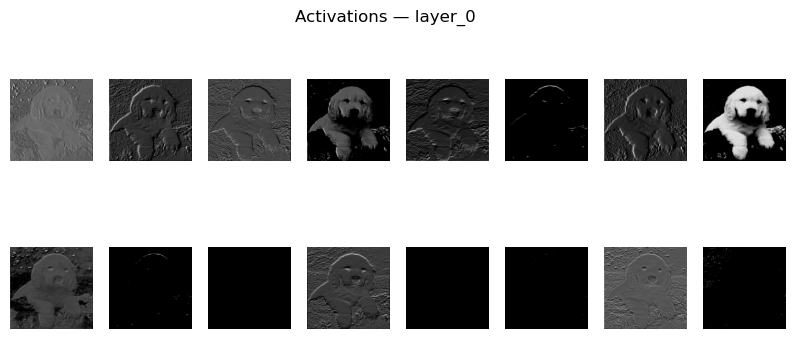

layer_3: shape torch.Size([64, 224, 224])


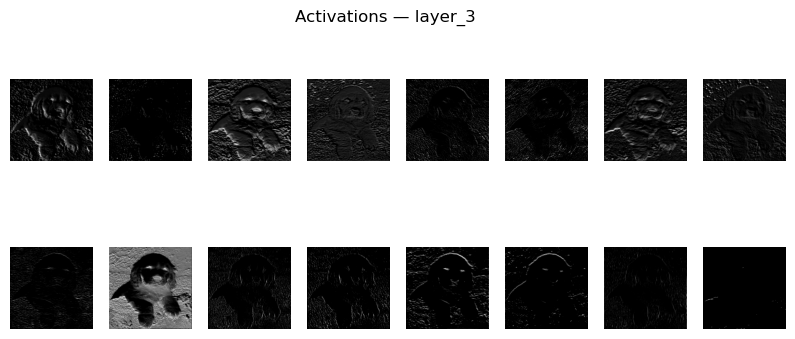

In [37]:
def get_feature_maps(model, x, layers=(0, 3)):
    activations = {}
    hooks = []

    def get_hook(name):
        def hook_fn(m, i, o):
            activations[name] = o.detach()
        return hook_fn

    for idx in layers:
        layer = model.features[idx]
        hook = layer.register_forward_hook(get_hook(f"layer_{idx}"))
        hooks.append(hook)

    _ = model.features(x)

    for hook in hooks:
        hook.remove()

    return activations

acts = get_feature_maps(model, img_tensor, layers=(0, 3))

for name, feat in acts.items():
    fmap = feat[0].cpu()
    print(f"{name}: shape {fmap.shape}")
    n = 16
    cols = 8
    rows = n // cols
    plt.figure(figsize=(10, 4))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(fmap[i], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Activations — {name}")
    plt.show()

## 16.6. Comparação com filtros clássicos de Processamento Digital de Imagem

Para compreender melhor o significado das ativações observadas na VGG16, nesta célula aplicamos alguns **filtros clássicos de deteção de padrões** à mesma imagem em tons de cinzento.

### 1. Filtros utilizados

- **Sobel:** calcula o gradiente da imagem em duas direções (horizontal e vertical), realçando **bordas e transições abruptas de intensidade**.  
  O módulo do gradiente (`sobel_mag`) combina ambas as direções e fornece uma estimativa da magnitude da variação local.

- **Laplace:** mede a **segunda derivada espacial**, destacando regiões de variação rápida de luminosidade — útil para **detetar contornos fechados** e mudanças bruscas.

- **Gabor:** atua como um **filtro direcional e seletivo em frequência**, semelhante a recetores visuais no córtex humano.  
  No exemplo, é usado um filtro com orientação de 45° (`theta = π/4`) e frequência espacial moderada (`freq = 0.2`), captando **texturas diagonais e padrões periódicos**.

### 2. Interpretação visual

Comparando os resultados:
- O **Sobel** evidencia o contorno do cão e das juntas do pavimento.  
- O **Laplace** destaca regiões de forte contraste, produzindo uma aparência de “relevo”.  
- O **Gabor** responde seletivamente às texturas diagonais, revelando padrões que evocam **sensibilidade direcional**, semelhante à de alguns filtros da CNN.

### 3. Ligação ao modelo convolucional

Esta comparação ilustra um ponto fundamental:
> As primeiras camadas de uma rede convolucional moderna, como a VGG16, **reaprendem automaticamente operações análogas a estes filtros clássicos**, mas de forma **otimizada pelos dados** e **combinada em centenas de direções e frequências possíveis**.

Assim, a transição entre *Processamento Digital de Imagem tradicional* e *Visão Computacional moderna* é mais de **continuidade evolutiva** do que de rutura:  
os princípios matemáticos são os mesmos — o que muda é a **escala, a densidade e a aprendizagem automática dos parâmetros.**

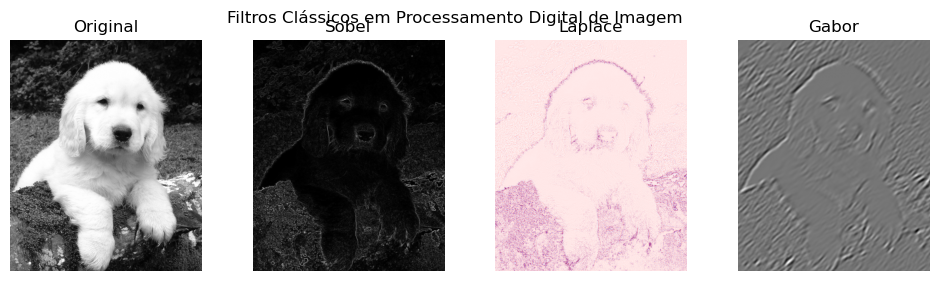

In [47]:
gray = transforms.Grayscale()(img_pil)
gray_np = np.array(gray.convert("L"), dtype=float)

# Sobel
sobel_x = ndimage.sobel(gray_np, axis=0)
sobel_y = ndimage.sobel(gray_np, axis=1)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)


# Laplace
L = ndimage.laplace(gray_np, mode="reflect")
laplace = L - L.mean()

# Gabor
def gabor_filter(theta, freq=0.2):
    sigma = 3
    x = np.linspace(-4, 4, 32)
    y = np.linspace(-4, 4, 32)
    X, Y = np.meshgrid(x, y)
    Xr = X * np.cos(theta) + Y * np.sin(theta)
    Yr = -X * np.sin(theta) + Y * np.cos(theta)
    gabor = np.exp(-(Xr**2 + Yr**2)/(2*sigma**2)) * np.cos(2*np.pi*freq*Xr)
    return gabor

gabor = ndimage.convolve(gray_np, gabor_filter(np.pi/4))

fig, axs = plt.subplots(1, 4, figsize=(12, 3))
axs[0].imshow(gray_np, cmap="gray"); axs[0].set_title("Original")
axs[1].imshow(sobel_mag, cmap="gray"); axs[1].set_title("Sobel")
axs[2].imshow(laplace, cmap="seismic"); axs[2].set_title("Laplace")
axs[3].imshow(gabor, cmap="gray"); axs[3].set_title("Gabor")
for ax in axs: ax.axis("off")
plt.suptitle("Filtros Clássicos em Processamento Digital de Imagem")
plt.show()

## 16.7. [Future Work] — Atlas Visual de Filtros e Ativações
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Uma evolução natural deste notebook seria a criação de um **Atlas Visual de Filtros e Ativações**, concebido como um repositório comparativo que ilustra como diferentes arquiteturas convolucionais percebem padrões visuais.

### Pipeline proposto

| Etapa | Ação | Resultado esperado |
|-------|------|--------------------|
| **1. Seleção de modelos** | Incluir várias redes pré-treinadas (VGG16, ResNet18, EfficientNet-B0). | Diversidade de arquiteturas e profundidades. |
| **2. Extração de filtros** | Recolher os *kernels* das primeiras camadas convolucionais de cada rede. | Mini-galeria de filtros aprendidos. |
| **3. Conjunto de imagens de teste** | Selecionar um conjunto de 6–8 imagens temáticas (animais, texturas, objetos, cenas naturais). | Base comum para comparação entre redes. |
| **4. Cálculo das ativações** | Passar cada imagem pelas redes e guardar os *feature maps* das camadas iniciais. | Representações 3D (C×H×W) para cada par rede-imagem. |
| **5. Curadoria visual** | Mostrar, lado a lado: <br>a) o filtro; <br>b) a imagem original; <br>c) a ativação correspondente. | Grelhas comparativas (*triplets* visuais). |
| **6. Metadados automáticos** | Adicionar informações de camada, dimensão e estatísticas (`mean`, `std`) de cada mapa. | Contextualização interpretativa. |

### Extensões possíveis

- Gerar automaticamente *montages* ou PDFs com `matplotlib` ou `PIL.ImageOps`.  
- Agrupar as visualizações por tipo de padrão (bordas, texturas, transições).  
- Calcular **correlações** entre filtros clássicos (Sobel, Laplace, Gabor) e filtros aprendidos, quantificando a semelhança estrutural.  
- Integrar um modo interativo com `Dash` ou `Gradio` para explorar camadas e canais.

### Valor didático

O Atlas funcionaria como uma **cartografia da visão artificial**, permitindo observar:
- a continuidade entre os operadores clássicos e as redes profundas;  
- a diversidade de respostas entre arquiteturas;  
- e a evolução progressiva da representação visual, desde o pixel até à abstração semântica.  

Para o estudante, seria uma ferramenta de referência e exploração comparativa —  
uma forma de “abrir a caixa negra” das CNNs e visualizar o que cada rede *vê*.

## 16.8. Conclusões

Neste capítulo explorámos a continuidade entre o **Processamento Digital de Imagem clássico** e a **Visão Computacional moderna baseada em redes convolucionais**, evidenciando como ambos assentam nos mesmos princípios matemáticos — convolução, derivação e filtragem espacial.

1. **Filtros aprendidos e filtros clássicos**  
   As primeiras camadas da VGG16 revelaram padrões de ativação análogos aos produzidos por filtros Sobel, Laplace ou Gabor.  
   A diferença essencial é que, nas redes neurais, estes filtros **não são definidos manualmente**, mas **aprendidos automaticamente** a partir dos dados.

2. **Hierarquia de representações**  
   As ativações mostraram a progressão típica de uma rede convolucional:  
   - as primeiras camadas respondem a **bordas e contrastes locais**,  
   - as seguintes sintetizam **texturas e formas mais complexas**,  
   - e as camadas profundas integram essas informações em **conceitos semânticos**.

3. **Papel dos operadores clássicos**  
   O Sobel, o Laplace e o Gabor ilustram as três dimensões fundamentais da análise visual — **orientação, curvatura e frequência**.  
   Embora simples, estes operadores representam a base conceitual sobre a qual as CNNs constroem representações cada vez mais ricas.

4. **Síntese final**  
   As redes convolucionais não substituem o processamento digital de imagem: **ampliam-no**.  
   Automatizam a descoberta e a combinação dos filtros adequados, permitindo que os princípios clássicos sejam aplicados em escala e de forma adaptativa.

> Em suma, a visão artificial moderna é a evolução natural do processamento de imagem:  
> os mesmos fundamentos matemáticos, agora potenciados pela aprendizagem automática.